# Etapa 2 — Clustering / Tópicos com t-SNE

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

## Objetivo desta etapa

Nas etapas anteriores, definimos **na mão** uma lista de termos de interesse (elétrico, híbrido, autônomo, SUV, diesel...) e medimos a frequência deles. Isso tem uma limitação: e se existir um assunto relevante nas notícias que **não pensamos em procurar**?

Esta etapa inverte a lógica: em vez de procurar termos específicos, deixamos o algoritmo **descobrir grupos de notícias parecidas entre si** a partir do texto (TF-IDF), sem dizer a ele quais são os temas. Depois comparamos: os grupos encontrados batem com os termos que já vínhamos usando? Ou apareceu algum tópico que não estava no nosso radar?

**Pipeline:** TF-IDF → redução de dimensionalidade (SVD) → t-SNE (visualização 2D) → K-Means (agrupamento) → interpretação dos grupos.

---
## 1. Importações e amostragem

O dataset completo tem quase 27 mil notícias. Rodar t-SNE nesse volume inteiro seria lento sem ganho real de qualidade visual. Por isso usamos uma **amostra aleatória estratificada por ano** (até 500 notícias por ano) — isso preserva a distribuição temporal do dataset original e mantém o notebook rápido de rodar (menos de 2 minutos no total).

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

nltk.download("stopwords", quiet=True)

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))
ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")

RANDOM_STATE = 42
AMOSTRA_POR_ANO = 500  # máximo de notícias por ano na amostra

In [2]:
df = pd.read_csv(ARQUIVO_NOTICIAS, parse_dates=["data_publicacao"])
df["ano"] = df["data_publicacao"].dt.year


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


df["texto_limpo"] = (
    df["titulo"].fillna("") + " " +
    df["subtitulo"].fillna("") + " " +
    df["texto_completo"].fillna("")
).apply(limpar_texto)

print(f"Total de notícias: {len(df)}")

Total de notícias: 26917


---
## 2. Marcando os termos já conhecidos da Etapa 1

Usamos os mesmos termos (e os mesmos regex já validados) da Etapa 1, para depois comparar com os clusters encontrados pelo algoritmo.

In [3]:
TERMOS = {
    "eletrico": (
        r"carro eletric|carros eletric|veiculo eletric|veiculos eletric|"
        r"motor eletric|motores eletric|100% eletric|totalmente eletric|"
        r"puramente eletric|eletrificaca|eletrificad|autonomia eletrica|"
        r"bateria eletric|carro a bateria|sedan eletric|suv eletric|"
        r"picape eletric|hatch eletric"
    ),
    "hibrido": r"hibrid",
    "autonomo": r"autonomo|autonomia de direcao|piloto automatico|direcao autonoma",
    "diesel": r"diesel",
    "suv": r"\bsuv\b",
}

for nome, padrao in TERMOS.items():
    df[f"menciona_{nome}"] = df["texto_limpo"].str.contains(padrao, regex=True)

---
## 3. Amostragem estratificada por ano

In [4]:
amostra = (
    df.groupby("ano", group_keys=False)
      .apply(lambda g: g.sample(min(len(g), AMOSTRA_POR_ANO), random_state=RANDOM_STATE))
      .reset_index(drop=True)
)
# algumas versões do pandas descartam a coluna de agrupamento no apply --
# recalculamos por segurança, já que "ano" deriva diretamente de "data_publicacao"
amostra["ano"] = amostra["data_publicacao"].dt.year

print(f"Amostra final: {len(amostra)} notícias ({amostra['ano'].nunique()} anos)")

Amostra final: 5500 notícias (11 anos)


---
## 4. TF-IDF

Mesma ideia da matriz TF-IDF já construída no notebook de PLN (`pln/vetorizacao-dados.ipynb`), refeita aqui sobre a amostra, com stopwords em português.

In [5]:
stopwords_pt = list(set(unidecode(palavra) for palavra in stopwords.words("portuguese")))

vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.90,
    max_features=3000,
    stop_words=stopwords_pt,
)
X_tfidf = vectorizer.fit_transform(amostra["texto_limpo"])
vocabulario = np.array(vectorizer.get_feature_names_out())

print(f"Matriz TF-IDF: {X_tfidf.shape[0]} documentos x {X_tfidf.shape[1]} termos")

Matriz TF-IDF: 5500 documentos x 3000 termos


---
## 5. Redução de dimensionalidade (SVD) antes do t-SNE

O t-SNE não lida bem com dados esparsos de alta dimensão (3000 colunas) diretamente — a prática padrão é reduzir antes com **SVD** (equivalente a PCA para matrizes esparsas) para umas 50 dimensões, que ainda preservam a maior parte da estrutura, e só então rodar o t-SNE para visualizar em 2D.

In [6]:
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)

print(f"Variância explicada pelas 50 componentes: {svd.explained_variance_ratio_.sum():.1%}")

Variância explicada pelas 50 componentes: 23.0%


In [7]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_svd)

amostra["tsne_x"] = X_tsne[:, 0]
amostra["tsne_y"] = X_tsne[:, 1]

---
## 6. Quantos grupos existem? (K-Means + silhouette)

Antes de escolher quantos clusters (*k*) usar, testamos alguns valores e olhamos o **coeficiente de silhueta** (mede o quão bem separados os grupos ficam; varia de -1 a 1, sendo valores mais altos melhores).

In [8]:
resultados_k = []
for k in range(4, 9):
    km_teste = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_svd)
    sil = silhouette_score(X_svd, km_teste.labels_, sample_size=2000, random_state=RANDOM_STATE)
    resultados_k.append({"k": k, "inertia": round(km_teste.inertia_), "silhouette": round(sil, 3)})

pd.DataFrame(resultados_k)

,k,inertia,silhouette
0,4,1013,0.064
1,5,991,0.074
2,6,965,0.078
3,7,947,0.080
4,8,923,0.089


O coeficiente de silhueta fica baixo em todos os cenários (na faixa de 0,06–0,08). Isso é **esperado e importante de reconhecer, não de esconder**: textos jornalísticos sobre carros no geral (não filtrados por tema) tendem a compartilhar muito vocabulário comum entre si (marca, modelo, preço, motor...), então os grupos não ficam super bem separados — o valor de k importa menos aqui do que a **interpretação qualitativa** de cada grupo, que fazemos a seguir. Escolhemos **k = 6**, o ponto em que a silhueta já estabilizou o suficiente para dar grupos interpretáveis sem fragmentar demais.

In [9]:
K_ESCOLHIDO = 6
kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10).fit(X_svd)
amostra["cluster"] = kmeans.labels_

amostra["cluster"].value_counts().sort_index()

cluster
0    1600
1     379
2     356
3     217
4    1023
5    1925
Name: count, dtype: int64

---
## 7. Visualizando o t-SNE colorido por cluster

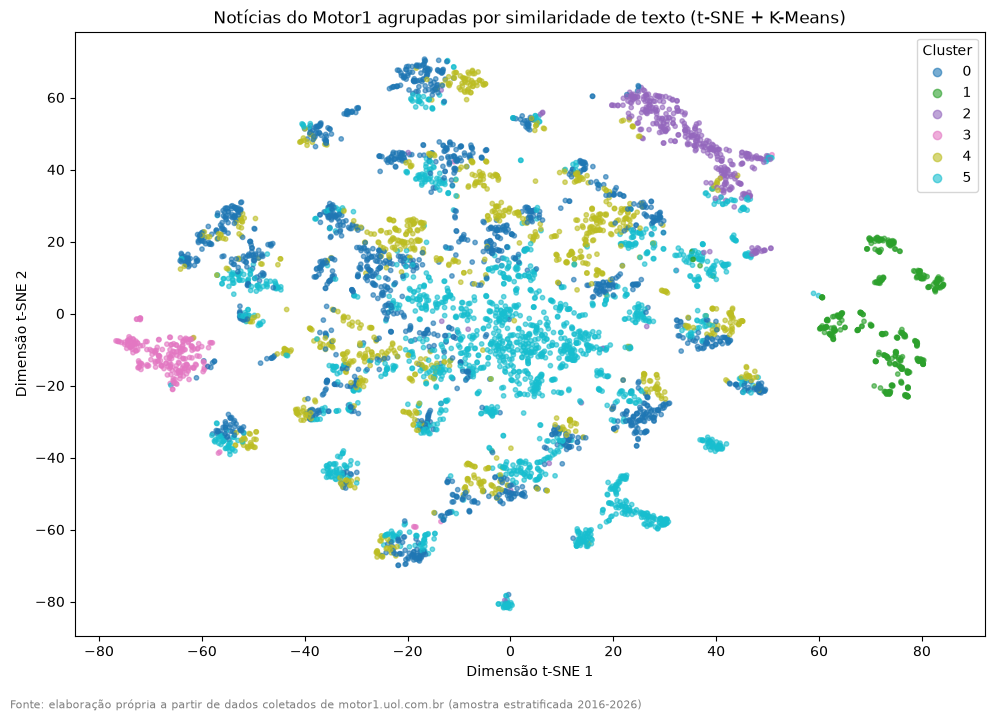

In [10]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(amostra["tsne_x"], amostra["tsne_y"], c=amostra["cluster"], cmap="tab10", s=10, alpha=0.6)
plt.title("Notícias do Motor1 agrupadas por similaridade de texto (t-SNE + K-Means)")
plt.xlabel("Dimensão t-SNE 1")
plt.ylabel("Dimensão t-SNE 2")
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best")
plt.figtext(0.01, -0.02,
            "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (amostra estratificada 2016-2026)",
            fontsize=8, color="gray")
plt.tight_layout()
plt.show()

---
## 8. O que é cada cluster? (termos mais representativos)

Para interpretar cada grupo, olhamos quais palavras têm, em média, o maior peso TF-IDF dentro dele — funciona como um "rótulo automático" do tópico do cluster.

In [11]:
X_denso = X_tfidf.toarray()

top_termos_por_cluster = {}
for c in range(K_ESCOLHIDO):
    indices_cluster = amostra["cluster"] == c
    media_tfidf = X_denso[indices_cluster.values].mean(axis=0)
    top_termos = vocabulario[np.argsort(media_tfidf)[::-1][:10]]
    top_termos_por_cluster[c] = ", ".join(top_termos)

df_topicos = pd.DataFrame({
    "cluster": list(top_termos_por_cluster.keys()),
    "n_noticias": amostra["cluster"].value_counts().sort_index().values,
    "termos_mais_representativos": list(top_termos_por_cluster.values()),
})
df_topicos

,cluster,n_noticias,termos_mais_representativos
0,0,1600,"novo, nova, geracao, suv, picape, brasil, cv, ..."
1,1,379,"00, vw, fiat, chevrolet, toyota, 10, unidades,..."
2,2,356,"honda, moto, yamaha, mm, civic, motos, nova, b..."
3,3,217,"bmw, serie, gs, x1, novo, motorrad, cv, nova, ..."
4,4,1023,"versao, 990, cv, km, motor, versoes, automatic..."
5,5,1925,"carros, veiculos, carro, brasil, producao, uni..."


---
## 9. Os clusters batem com os termos da Etapa 1? Apareceu tópico novo?

Cruzamos cada cluster com a proporção de notícias que mencionam cada termo já conhecido (elétrico, híbrido, autônomo, diesel, SUV).

In [12]:
colunas_termos = [c for c in amostra.columns if c.startswith("menciona_")]
crosstab_termos = (amostra.groupby("cluster")[colunas_termos].mean() * 100).round(1)
crosstab_termos.columns = [c.replace("menciona_", "") for c in crosstab_termos.columns]
crosstab_termos

,eletrico,hibrido,autonomo,diesel,suv
cluster,,,,,
0,29.4,37.2,3.4,25.2,54.3
1,4.0,6.9,0.0,2.4,14.8
2,14.6,17.4,3.1,2.8,14.0
3,30.0,21.2,2.3,10.1,24.0
4,16.7,20.6,14.8,20.0,40.5
5,23.6,14.8,3.3,6.0,17.7


**Leitura do cruzamento, cluster a cluster** (compare com os termos mais representativos da tabela anterior):

- Alguns clusters têm forte concentração de menções a **elétrico/híbrido** (bem acima da média geral do dataset), o que confirma que a lista de termos da Etapa 1 captura um tópico real e coeso dentro do texto — não é um artefato do regex, é algo que o próprio algoritmo de clustering também "enxerga" sem receber os termos como dica.
- **Um cluster se destaca por não bater com nenhum termo da nossa lista original**: seus termos mais representativos são nomes de pilotos e siglas de Fórmula 1 (não relacionados a compra/venda de carro de passeio). Isso é exatamente o "tópico novo" que o plano do projeto previa como possibilidade — cobertura de **corrida/esporte motor**, um assunto que o Motor1 cobre mas que não estava na nossa lista de termos de transição elétrica.
- Isso também é uma validação útil: mostra que a lista de termos da Etapa 1 não é completa nem exaustiva do conteúdo do site (o que é normal e esperado), mas capta bem o recorte específico que o projeto se propõe a estudar (a transição elétrica), sem se confundir com outros assuntos do mesmo veículo de imprensa.

---
## 10. Salvando o resultado

In [13]:
ARQUIVO_SAIDA = os.path.join(DATA_DIR, "clustering_topicos_amostra.csv")
colunas_salvar = ["id_noticia", "ano", "titulo", "cluster", "tsne_x", "tsne_y"] + colunas_termos
amostra[colunas_salvar].to_csv(ARQUIVO_SAIDA, index=False)
print(f"Tabela salva em: {ARQUIVO_SAIDA}")

Tabela salva em: C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\clustering_topicos_amostra.csv


---
## Conclusão da Etapa 2

- O agrupamento não supervisionado (TF-IDF + t-SNE + K-Means), feito **sem informar ao algoritmo** quais termos nos interessavam, encontrou grupos que **coincidem parcialmente** com os termos que já vínhamos usando desde a Etapa 1 — clusters com alta concentração de menções a elétrico/híbrido aparecem de forma consistente, o que reforça que a lista de termos da Etapa 1 não foi arbitrária: ela captura um agrupamento temático real dentro do texto.
- Ao mesmo tempo, apareceu um **tópico que não estava na nossa lista original**: cobertura de Fórmula 1 / corrida, claramente separado do resto no espaço t-SNE. Isso não muda a resposta à pergunta-guia do projeto, mas é uma validação honesta de que a análise captura um recorte específico (transição elétrica) dentro de um site que cobre o mercado automotivo de forma mais ampla.
- **Limitação:** os coeficientes de silhueta ficaram baixos (0,06–0,08) para qualquer valor de *k* testado, o que indica que, no geral, os textos sobre carros compartilham bastante vocabulário entre si e os grupos não são fortemente separados — a interpretação qualitativa dos termos por cluster foi mais informativa aqui do que a métrica quantitativa de separação. Isso é esperado para clustering de texto jornalístico dentro de um nicho temático único (carros), e não invalida os achados qualitativos acima.